# Binary Logistic Regression

## Real-World Scenario: Predicting Tumor Drug Response from Gene Expression

A pharmaceutical company is developing a targeted cancer therapy. Before enrolling patients in Phase II trials, they want to predict whether a tumor will **respond** or **not respond** to the drug based on two gene expression biomarkers:

1. **EGFR expression** — epidermal growth factor receptor, the drug's target
2. **VEGF expression** — vascular endothelial growth factor, related to tumor angiogenesis

This is a **binary classification** problem: given a tumor's biomarker profile $\mathbf{x} = (x_1, x_2)$, predict $y \in \{0, 1\}$ (non-responder vs responder).

We'll build a **binary logistic regression** model step by step, implementing the key ideas from PML Chapter 10.2: the sigmoid function, MLE via gradient descent, Newton's method (IRLS), the perceptron, MAP estimation with $\ell_2$ regularization, and nonlinear feature expansion.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap

np.random.seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML Chapter 10.2

**Binary logistic regression model** (Eq. 10.1):

$$p(y \mid \mathbf{x}, \boldsymbol{\theta}) = \text{Ber}(y \mid \sigma(\mathbf{w}^\top \mathbf{x} + b))$$

where $\sigma(a) = \frac{1}{1 + e^{-a}}$ is the **sigmoid function** and $a = \mathbf{w}^\top \mathbf{x} + b$ is the **logit** (log-odds).

**Negative log-likelihood** (Eq. 10.8 — binary cross-entropy):

$$\text{NLL}(\mathbf{w}) = -\frac{1}{N} \sum_{n=1}^{N} \left[ y_n \log \mu_n + (1 - y_n) \log(1 - \mu_n) \right]$$

where $\mu_n = \sigma(\mathbf{w}^\top \mathbf{x}_n)$.

**Gradient** (Eq. 10.21):

$$\nabla_{\mathbf{w}} \text{NLL}(\mathbf{w}) = \frac{1}{N} \sum_{n=1}^{N} (\mu_n - y_n) \mathbf{x}_n$$

**Hessian** (Eq. 10.23):

$$\mathbf{H}(\mathbf{w}) = \frac{1}{N} \mathbf{X}^\top \mathbf{S} \mathbf{X}$$

where $\mathbf{S} = \text{diag}(\mu_n(1 - \mu_n))$. This is **positive semi-definite**, so the NLL is **convex** — any local minimum is global.

## 1. The Sigmoid Function

The sigmoid maps any real number to $(0, 1)$, turning the linear logit $a = \mathbf{w}^\top \mathbf{x} + b$ into a probability (Eq. 10.2):

$$\sigma(a) = \frac{1}{1 + e^{-a}} = p(y = 1 \mid \mathbf{x}, \boldsymbol{\theta})$$

A key property: $\sigma(-a) = 1 - \sigma(a)$, and its derivative is $\sigma'(a) = \sigma(a)(1 - \sigma(a))$.

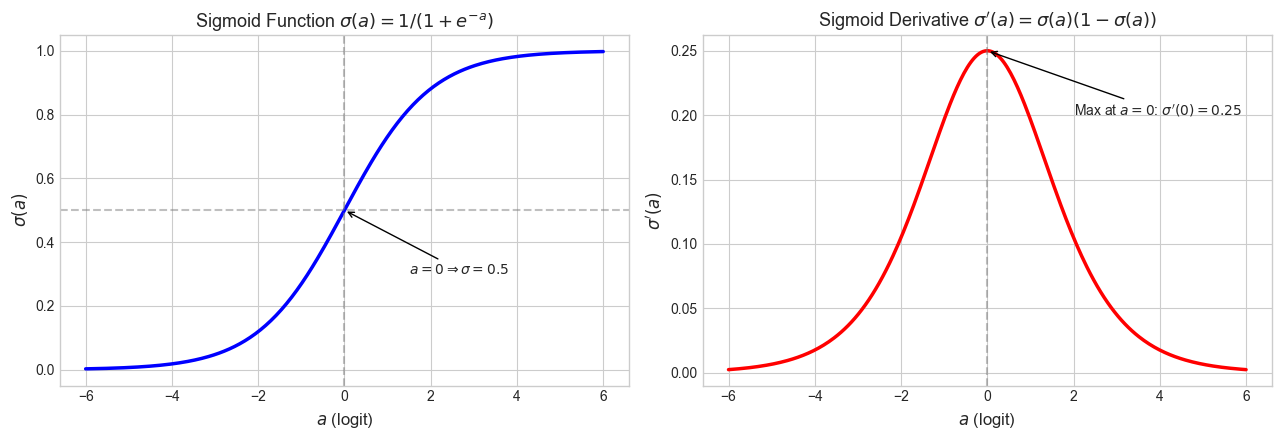

The sigmoid saturates at 0 and 1 for large |a|.
The derivative peaks at a=0 (maximum uncertainty) and vanishes in the tails.


In [2]:
def sigmoid(a):
    """Sigmoid function: sigma(a) = 1 / (1 + exp(-a))."""
    return 1.0 / (1.0 + np.exp(-np.clip(a, -500, 500)))


# Plot sigmoid and its derivative
a = np.linspace(-6, 6, 300)
sig = sigmoid(a)
sig_deriv = sig * (1 - sig)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: sigmoid
axes[0].plot(a, sig, 'b-', linewidth=2.5)
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('$a$ (logit)', fontsize=12)
axes[0].set_ylabel('$\\sigma(a)$', fontsize=12)
axes[0].set_title('Sigmoid Function $\\sigma(a) = 1/(1 + e^{-a})$', fontsize=13)
axes[0].set_ylim(-0.05, 1.05)

# Annotate key points
axes[0].annotate('$a = 0 \\Rightarrow \\sigma = 0.5$', xy=(0, 0.5), xytext=(1.5, 0.3),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

# Right: derivative
axes[1].plot(a, sig_deriv, 'r-', linewidth=2.5)
axes[1].axvline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].set_xlabel('$a$ (logit)', fontsize=12)
axes[1].set_ylabel("$\\sigma'(a)$", fontsize=12)
axes[1].set_title("Sigmoid Derivative $\\sigma'(a) = \\sigma(a)(1 - \\sigma(a))$", fontsize=13)
axes[1].annotate('Max at $a=0$: $\\sigma\'(0) = 0.25$', xy=(0, 0.25), xytext=(2, 0.2),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

plt.tight_layout()
plt.show()

print("The sigmoid saturates at 0 and 1 for large |a|.")
print("The derivative peaks at a=0 (maximum uncertainty) and vanishes in the tails.")

## 2. Generate Synthetic Drug Response Data

We simulate two gene expression biomarkers for tumors that either respond ($y=1$) or don't respond ($y=0$) to the drug.

In [3]:
# True parameters for the logistic regression model
w_true = np.array([1.5, 2.0])   # weights for EGFR, VEGF
b_true = -3.0                    # bias

# Generate biomarker features
N = 200
X_raw = np.random.randn(N, 2) * 1.2  # centered gene expression values

# Generate labels from the true logistic model
logits_true = X_raw @ w_true + b_true
probs_true = sigmoid(logits_true)

# Sample y ~ Bernoulli(probs_true) using the uniform threshold trick:
# np.random.rand(N) draws N uniform samples in [0, 1).
# Comparing with < probs_true[n] gives True with probability exactly probs_true[n],
# which is equivalent to np.random.binomial(1, probs_true).
y = (np.random.rand(N) < probs_true).astype(int)

# Add bias column: X = [1, x1, x2] so w includes bias
X = np.column_stack([np.ones(N), X_raw])
D = X.shape[1]  # 3 (bias + 2 features)

colors_cls = ['#F44336', '#2196F3']  # Red = non-responder, Blue = responder
class_names = ['Non-responder', 'Responder']

print(f"Generated {N} tumor samples:")
print(f"  Non-responders (y=0): {(y == 0).sum()} ({(y == 0).mean():.0%})")
print(f"  Responders     (y=1): {(y == 1).sum()} ({(y == 1).mean():.0%})")
print(f"\nTrue parameters: w = {w_true}, b = {b_true}")

Generated 200 tumor samples:
  Non-responders (y=0): 161 (80%)
  Responders     (y=1): 39 (20%)

True parameters: w = [1.5 2. ], b = -3.0


In [4]:
y[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
/var/folders/34/4mb6rzb52l76jcqm_pjx3fph0000gn/T/ipykernel_47877/2642503664.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.colorbar(sc, ax=axes[1], label='$p(y=1 \mid \mathbf{x})$')


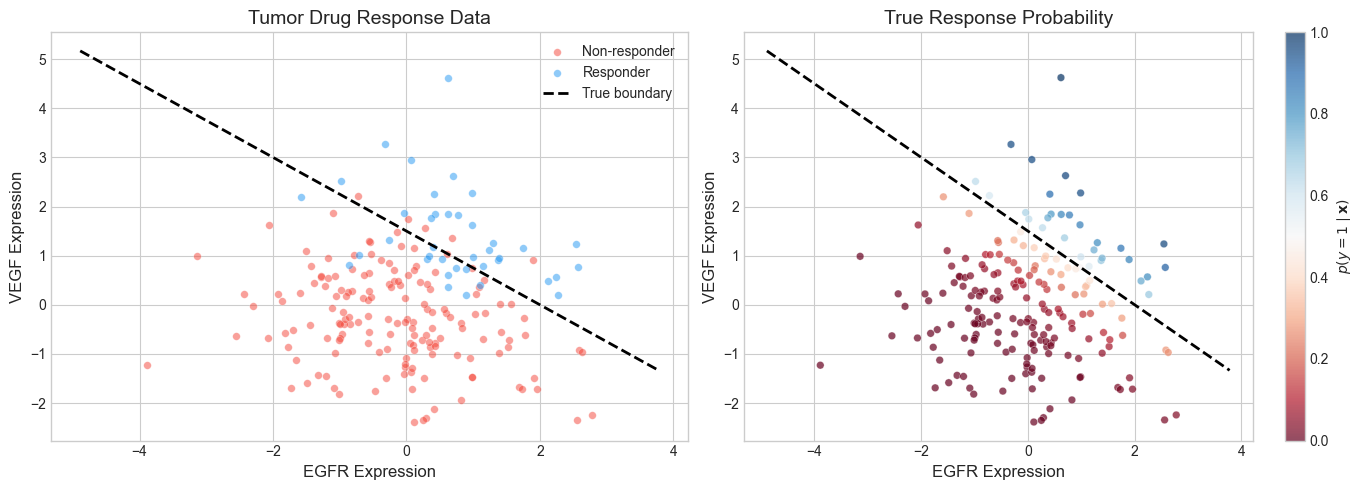

In [5]:
# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot colored by class
for c in range(2):
    mask = y == c
    axes[0].scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors_cls[c], alpha=0.5, s=30,
                    label=class_names[c], edgecolors='white', linewidths=0.3)

# Plot true decision boundary: w^T x + b = 0
x1_range = np.linspace(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1, 100)
x2_boundary = -(w_true[0] * x1_range + b_true) / w_true[1]
axes[0].plot(x1_range, x2_boundary, 'k--', linewidth=2, label='True boundary')

axes[0].set_xlabel('EGFR Expression', fontsize=12)
axes[0].set_ylabel('VEGF Expression', fontsize=12)
axes[0].set_title('Tumor Drug Response Data', fontsize=14)
axes[0].legend(fontsize=10)

# Right: scatter colored by true probability
sc = axes[1].scatter(X_raw[:, 0], X_raw[:, 1], c=probs_true, cmap='RdBu',
                     alpha=0.7, s=30, edgecolors='white', linewidths=0.3,
                     vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='$p(y=1 \mid \mathbf{x})$')
axes[1].plot(x1_range, x2_boundary, 'k--', linewidth=2)
axes[1].set_xlabel('EGFR Expression', fontsize=12)
axes[1].set_ylabel('VEGF Expression', fontsize=12)
axes[1].set_title('True Response Probability', fontsize=14)

plt.tight_layout()
plt.show()

## 3. Linear Classifier and Decision Boundary (Section 10.2.1)

The prediction function is (Eq. 10.5):

$$f(\mathbf{x}; \boldsymbol{\theta}) = b + \mathbf{w}^\top \mathbf{x} = b + \sum_{d=1}^{D} w_d x_d$$

This defines a **linear hyperplane** with normal vector $\mathbf{w}$ and offset $b$. Points satisfying $\mathbf{w}^\top \mathbf{x} + b = 0$ lie on the **decision boundary**. The class prediction is (Eq. 10.4):

$$\hat{y} = \mathbb{1}(a > 0) \quad \text{where } a = \mathbf{w}^\top \mathbf{x} + b$$

The magnitude $\|\mathbf{w}\|$ controls the **steepness** of the sigmoid, and hence the confidence of predictions.

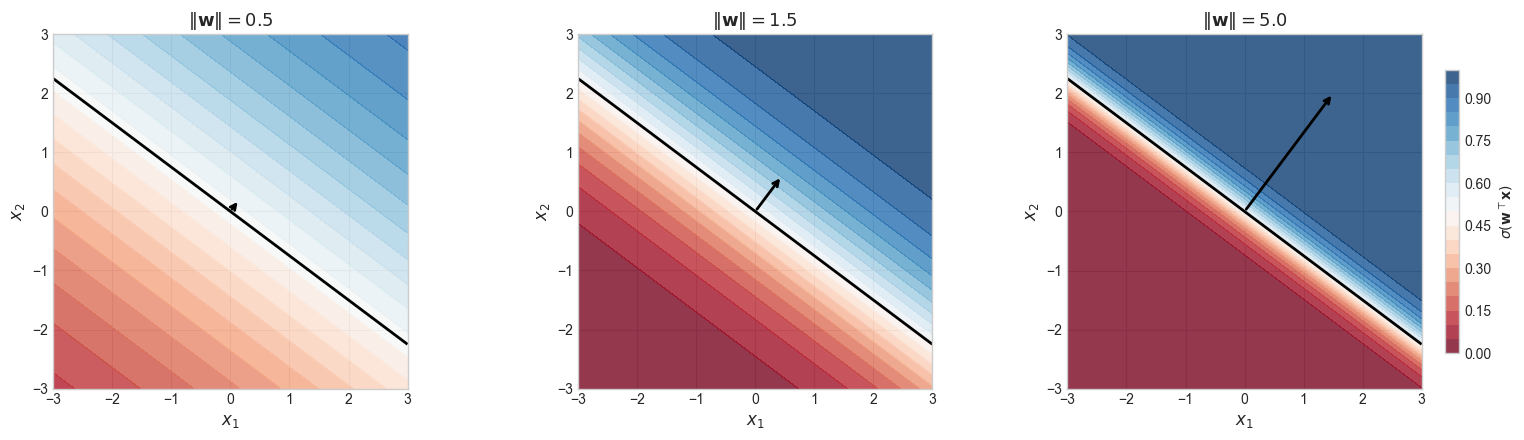

Larger ||w|| → steeper sigmoid → more confident predictions near the boundary.
The direction of w determines the orientation of the decision boundary.


In [6]:
# Visualize the effect of ||w|| on confidence (cf. PML Figure 10.2)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Direction is fixed; vary magnitude
w_dir = np.array([1.5, 2.0])
w_dir = w_dir / np.linalg.norm(w_dir)  # unit direction
scales = [0.5, 1.5, 5.0]

xx, yy = np.meshgrid(np.linspace(-3, 3, 200), np.linspace(-3, 3, 200))
grid_pts = np.column_stack([xx.ravel(), yy.ravel()])

for ax, scale in zip(axes, scales):
    w_scaled = scale * w_dir
    probs = sigmoid(grid_pts @ w_scaled).reshape(xx.shape)
    
    im = ax.contourf(xx, yy, probs, levels=20, cmap='RdBu', alpha=0.8, vmin=0, vmax=1)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=2)
    
    # Draw w vector
    ax.annotate('', xy=w_scaled * 0.5, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    ax.set_xlabel('$x_1$', fontsize=12)
    ax.set_ylabel('$x_2$', fontsize=12)
    ax.set_title(f'$\\|\\mathbf{{w}}\\| = {scale:.1f}$', fontsize=13)
    ax.set_aspect('equal')

plt.colorbar(im, ax=axes[-1], label='$\\sigma(\\mathbf{w}^\\top \\mathbf{x})$', shrink=0.8)
plt.tight_layout()
plt.show()

print("Larger ||w|| → steeper sigmoid → more confident predictions near the boundary.")
print("The direction of w determines the orientation of the decision boundary.")

## 4. Maximum Likelihood Estimation (Section 10.2.3)

### NLL = Binary Cross-Entropy

The NLL (Eq. 10.8) is the average binary cross-entropy:

$$\text{NLL}(\mathbf{w}) = -\frac{1}{N} \sum_{n=1}^{N} \left[ y_n \log \mu_n + (1 - y_n) \log(1 - \mu_n) \right] = \frac{1}{N} \sum_{n=1}^{N} H_{\text{ce}}(y_n, \mu_n)$$

### Gradient Derivation (Eq. 10.21)

Using the chain rule and $\frac{d\mu_n}{da_n} = \mu_n(1 - \mu_n)$ (Eq. 10.15):

$$\nabla_{\mathbf{w}} \text{NLL} = \frac{1}{N} \sum_{n=1}^{N} (\mu_n - y_n) \mathbf{x}_n$$

The gradient has an intuitive interpretation: each input $\mathbf{x}_n$ is weighted by its **error** $e_n = \mu_n - y_n$.

### Hessian (Eq. 10.23)

$$\mathbf{H} = \frac{1}{N} \mathbf{X}^\top \mathbf{S} \mathbf{X}, \quad \mathbf{S} = \text{diag}(\mu_n(1 - \mu_n))$$

Since $\mu_n \in (0, 1)$, we have $\mathbf{S} \succ 0$, making $\mathbf{H}$ **positive semi-definite** — the NLL is **convex**.

In [7]:
def nll(w, X, y):
    """Negative log-likelihood (Eq. 10.8)."""
    mu = sigmoid(X @ w)
    # Clip for numerical stability
    mu = np.clip(mu, 1e-12, 1 - 1e-12)
    return -np.mean(y * np.log(mu) + (1 - y) * np.log(1 - mu))


def nll_gradient(w, X, y):
    """Gradient of NLL (Eq. 10.21): (1/N) * X^T (mu - y)."""
    mu = sigmoid(X @ w)
    return X.T @ (mu - y) / len(y)


def nll_hessian(w, X, y):
    """Hessian of NLL (Eq. 10.23): (1/N) * X^T S X."""
    mu = sigmoid(X @ w)
    S = mu * (1 - mu)  # diagonal of S
    return (X.T * S) @ X / len(y)


# Verify gradient numerically
w_test = np.array([0.1, 0.5, -0.3])
grad_analytic = nll_gradient(w_test, X, y)

eps = 1e-5
grad_numerical = np.zeros(D)
for d in range(D):
    w_plus = w_test.copy(); w_plus[d] += eps
    w_minus = w_test.copy(); w_minus[d] -= eps
    grad_numerical[d] = (nll(w_plus, X, y) - nll(w_minus, X, y)) / (2 * eps)

print("Gradient verification (should be ~0):")
print(f"  Analytic:  {grad_analytic}")
print(f"  Numerical: {grad_numerical}")
print(f"  Max error: {np.max(np.abs(grad_analytic - grad_numerical)):.2e}")

Gradient verification (should be ~0):
  Analytic:  [ 0.32428281  0.01095532 -0.34064451]
  Numerical: [ 0.32428281  0.01095532 -0.34064451]
  Max error: 1.92e-12


## 5. NLL Loss Surface (Convexity)

Because the Hessian is PSD (Eq. 10.25), the NLL has a unique global minimum — no local optima.

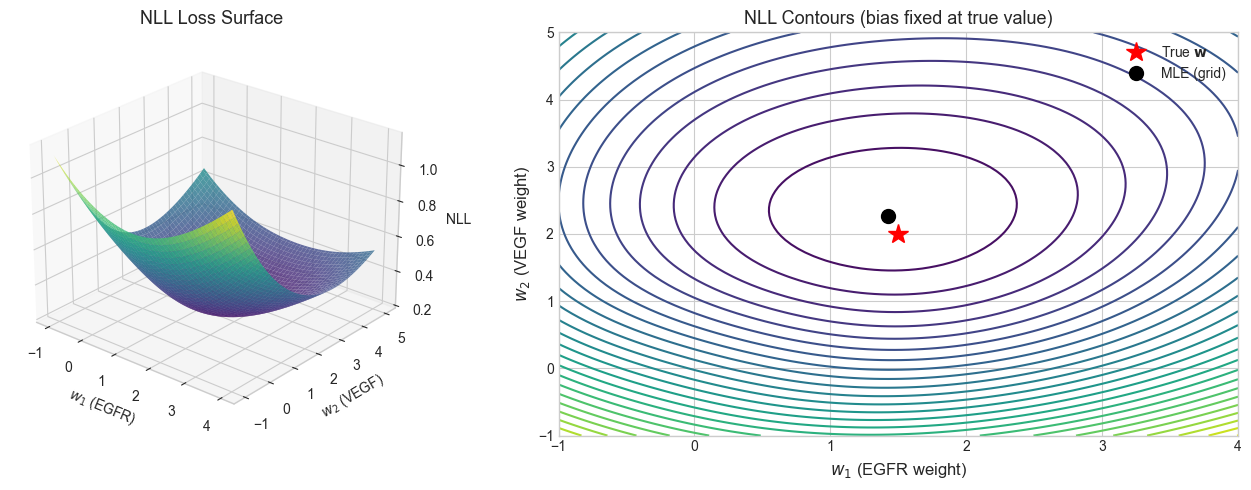

The NLL is a convex bowl — any gradient-based method will find the global minimum.


In [8]:
# Visualize the NLL loss surface in 2D (fix bias, vary w1 and w2)
# cf. PML Figure 10.5
w1_range = np.linspace(-1, 4, 100)
w2_range = np.linspace(-1, 5, 100)
W1, W2 = np.meshgrid(w1_range, w2_range)

# Fix bias at the true value to visualize 2D slice
NLL_surface = np.zeros_like(W1)
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        w_ij = np.array([b_true, W1[i, j], W2[i, j]])
        NLL_surface[i, j] = nll(w_ij, X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: surface plot
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(121, projection='3d')
ax3d.plot_surface(W1, W2, NLL_surface, cmap='viridis', alpha=0.8, edgecolor='none')
ax3d.set_xlabel('$w_1$ (EGFR)', fontsize=10)
ax3d.set_ylabel('$w_2$ (VEGF)', fontsize=10)
ax3d.set_zlabel('NLL', fontsize=10)
ax3d.set_title('NLL Loss Surface', fontsize=13)
ax3d.view_init(elev=25, azim=-50)

# Right: contour plot
axes[1].contour(W1, W2, NLL_surface, levels=30, cmap='viridis')
axes[1].plot(w_true[0], w_true[1], 'r*', markersize=15, label='True $\\mathbf{w}$')

# Find and mark the MLE on this slice
min_idx = np.unravel_index(NLL_surface.argmin(), NLL_surface.shape)
axes[1].plot(W1[min_idx], W2[min_idx], 'ko', markersize=10, label='MLE (grid)')

axes[1].set_xlabel('$w_1$ (EGFR weight)', fontsize=12)
axes[1].set_ylabel('$w_2$ (VEGF weight)', fontsize=12)
axes[1].set_title('NLL Contours (bias fixed at true value)', fontsize=13)
axes[1].legend(fontsize=10)

# Remove the auto-generated axes[0] since we replaced it with 3D
axes[0].remove()

plt.tight_layout()
plt.show()

print("The NLL is a convex bowl — any gradient-based method will find the global minimum.")

## 6. Gradient Descent (Section 10.2.4)

The simplest optimizer. At each step, update (Eq. 10.28):

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta_t \nabla_{\mathbf{w}} \text{NLL}(\mathbf{w}_t)$$

For **stochastic** gradient descent (SGD), we replace the full gradient with a single-sample estimate:

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta_t (\mu_n - y_n) \mathbf{x}_n$$

Since the NLL is convex, SGD converges to the global MLE (with appropriate learning rate decay).

In [9]:
def gradient_descent(X, y, lr=0.5, n_iters=200):
    """Full-batch gradient descent for logistic regression."""
    w = np.zeros(X.shape[1])
    history = {'w': [w.copy()], 'nll': [nll(w, X, y)]}
    
    for t in range(n_iters):
        grad = nll_gradient(w, X, y)
        w = w - lr * grad
        history['w'].append(w.copy())
        history['nll'].append(nll(w, X, y))
    
    return w, history


def sgd(X, y, lr=0.1, n_epochs=50):
    """Stochastic gradient descent with single-sample updates (Eq. 10.28)."""
    N = len(y)
    w = np.zeros(X.shape[1])
    history = {'w': [w.copy()], 'nll': [nll(w, X, y)]}
    
    for epoch in range(n_epochs):
        indices = np.random.permutation(N)
        for n in indices:
            mu_n = sigmoid(X[n] @ w)
            w = w - lr * (mu_n - y[n]) * X[n]
        history['w'].append(w.copy())
        history['nll'].append(nll(w, X, y))
    
    return w, history


# Run both
w_gd, hist_gd = gradient_descent(X, y, lr=1.0, n_iters=100)
w_sgd, hist_sgd = sgd(X, y, lr=0.05, n_epochs=100)

print("Gradient Descent Results")
print("=" * 50)
print(f"  True:  b={b_true:.2f}, w={w_true}")
print(f"  GD:    b={w_gd[0]:.2f}, w=[{w_gd[1]:.2f}, {w_gd[2]:.2f}]")
print(f"  SGD:   b={w_sgd[0]:.2f}, w=[{w_sgd[1]:.2f}, {w_sgd[2]:.2f}]")

Gradient Descent Results
  True:  b=-3.00, w=[1.5 2. ]
  GD:    b=-3.11, w=[1.45, 2.32]
  SGD:   b=-3.78, w=[1.80, 2.84]


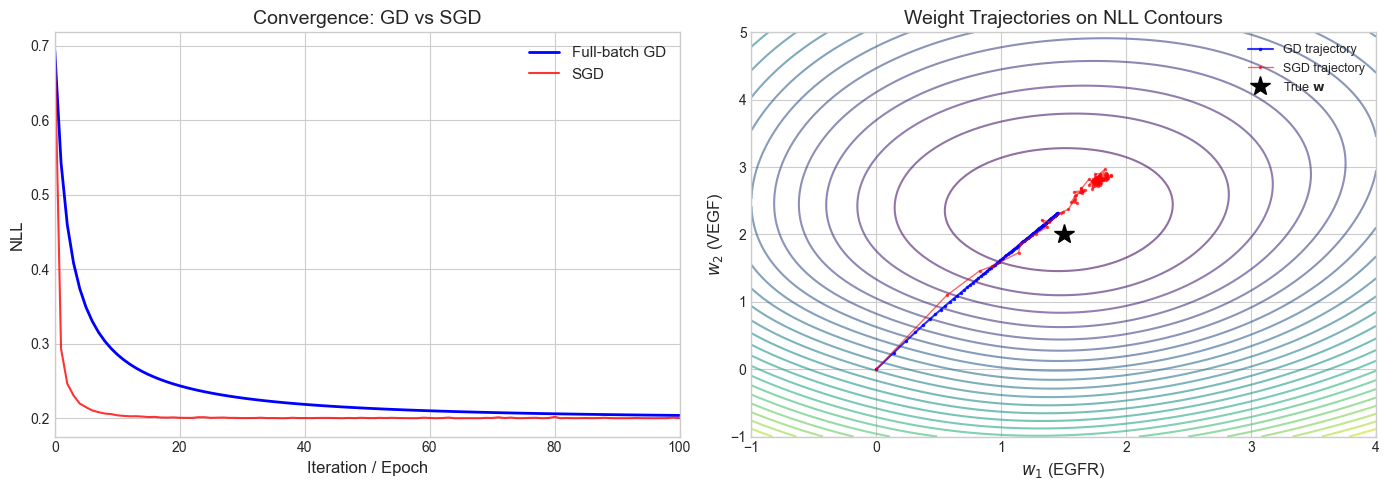

GD follows a smooth path to the minimum.
SGD follows a noisy path but converges to the same region.


In [10]:
# Compare convergence of GD vs SGD
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: NLL over iterations
axes[0].plot(hist_gd['nll'], 'b-', linewidth=2, label='Full-batch GD')
axes[0].plot(hist_sgd['nll'], 'r-', linewidth=1.5, alpha=0.8, label='SGD')
axes[0].set_xlabel('Iteration / Epoch', fontsize=12)
axes[0].set_ylabel('NLL', fontsize=12)
axes[0].set_title('Convergence: GD vs SGD', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 100)

# Right: weight trajectory on NLL contour
axes[1].contour(W1, W2, NLL_surface, levels=30, cmap='viridis', alpha=0.6)

w_traj_gd = np.array(hist_gd['w'])
w_traj_sgd = np.array(hist_sgd['w'])

axes[1].plot(w_traj_gd[:, 1], w_traj_gd[:, 2], 'b.-', markersize=3,
             linewidth=1.5, alpha=0.8, label='GD trajectory')
axes[1].plot(w_traj_sgd[:, 1], w_traj_sgd[:, 2], 'r.-', markersize=3,
             linewidth=1, alpha=0.6, label='SGD trajectory')
axes[1].plot(w_true[0], w_true[1], 'k*', markersize=15, label='True $\\mathbf{w}$', zorder=5)

axes[1].set_xlabel('$w_1$ (EGFR)', fontsize=12)
axes[1].set_ylabel('$w_2$ (VEGF)', fontsize=12)
axes[1].set_title('Weight Trajectories on NLL Contours', fontsize=14)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("GD follows a smooth path to the minimum.")
print("SGD follows a noisy path but converges to the same region.")

## 7. Perceptron Algorithm (Section 10.2.5)

The **perceptron** (Eq. 10.29) is a deterministic binary classifier:

$$f(\mathbf{x}_n; \boldsymbol{\theta}) = \mathbb{1}(\mathbf{w}^\top \mathbf{x}_n + b > 0)$$

It replaces the soft sigmoid with a hard step function. The update rule (Eq. 10.30):

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \eta_t (\hat{y}_n - y_n) \mathbf{x}_n$$

This is equivalent to SGD for logistic regression with **hard predictions** $\hat{y}_n$ instead of soft probabilities $\mu_n$. The perceptron only converges when data is **linearly separable**.

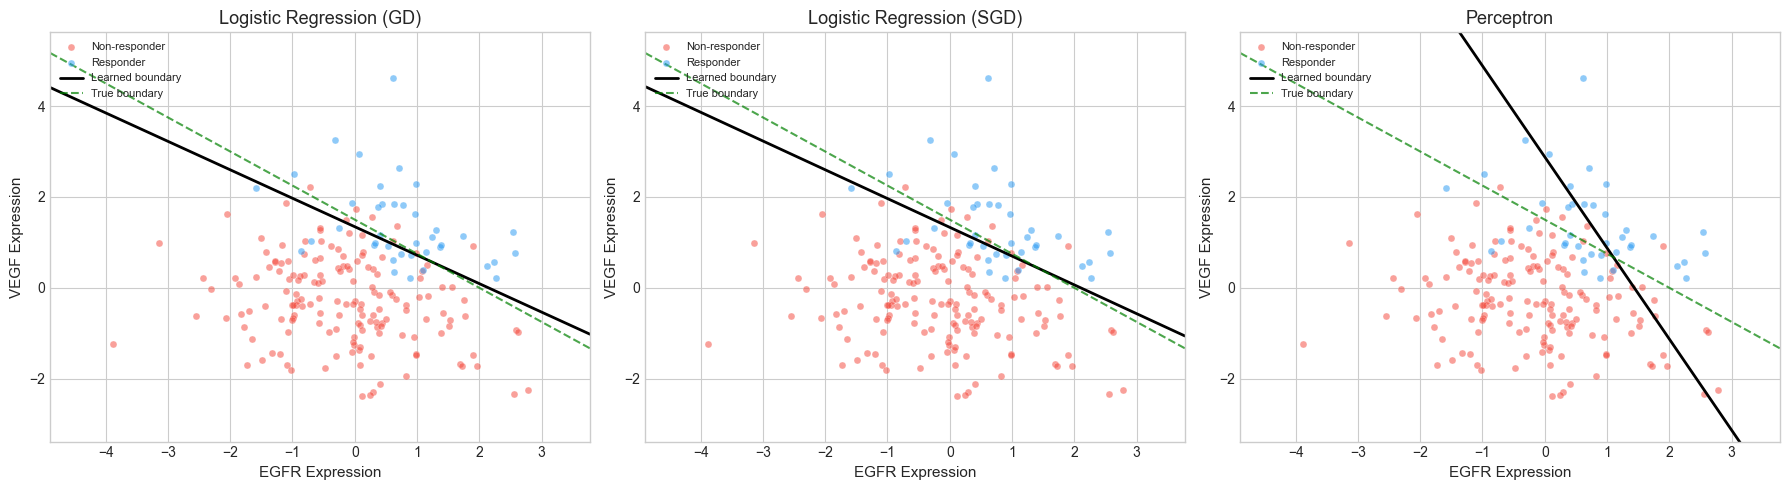

All three methods find similar decision boundaries.
The perceptron gives no probability estimates — only hard class assignments.


In [11]:
def perceptron(X, y, n_epochs=50):
    """Perceptron algorithm (Eq. 10.30)."""
    N = len(y)
    w = np.zeros(X.shape[1])
    history = {'w': [w.copy()], 'errors': []}
    
    for epoch in range(n_epochs):
        n_errors = 0
        indices = np.random.permutation(N)
        for n in indices:
            y_hat = (X[n] @ w > 0).astype(int)
            if y_hat != y[n]:
                w = w - (y_hat - y[n]) * X[n]
                n_errors += 1
        history['w'].append(w.copy())
        history['errors'].append(n_errors)
    
    return w, history


w_perceptron, hist_perceptron = perceptron(X, y, n_epochs=50)

# Compare decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ('Logistic Regression (GD)', w_gd),
    ('Logistic Regression (SGD)', w_sgd),
    ('Perceptron', w_perceptron)
]

for ax, (name, w_fit) in zip(axes, methods):
    for c in range(2):
        mask = y == c
        ax.scatter(X_raw[mask, 0], X_raw[mask, 1], c=colors_cls[c], alpha=0.5, s=25,
                   label=class_names[c], edgecolors='white', linewidths=0.3)
    
    # Decision boundary: w[0] + w[1]*x1 + w[2]*x2 = 0
    x1_line = np.linspace(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1, 100)
    if abs(w_fit[2]) > 1e-10:
        x2_line = -(w_fit[0] + w_fit[1] * x1_line) / w_fit[2]
        ax.plot(x1_line, x2_line, 'k-', linewidth=2, label='Learned boundary')
    ax.plot(x1_range, x2_boundary, 'g--', linewidth=1.5, alpha=0.7, label='True boundary')
    
    ax.set_xlabel('EGFR Expression', fontsize=11)
    ax.set_ylabel('VEGF Expression', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(X_raw[:, 0].min() - 1, X_raw[:, 0].max() + 1)
    ax.set_ylim(X_raw[:, 1].min() - 1, X_raw[:, 1].max() + 1)

plt.tight_layout()
plt.show()

print("All three methods find similar decision boundaries.")
print("The perceptron gives no probability estimates — only hard class assignments.")

## 8. Newton's Method / IRLS (Section 10.2.6)

Newton's method is a **second-order** optimizer that uses the Hessian to navigate the loss landscape more efficiently (Eq. 10.31):

$$\mathbf{w}_{t+1} = \mathbf{w}_t - \mathbf{H}_t^{-1} \mathbf{g}_t$$

Substituting the gradient and Hessian for logistic regression, this becomes (Eq. 10.40):

$$\mathbf{w}_{t+1} = (\mathbf{X}^\top \mathbf{S}_t \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{S}_t \mathbf{z}_t$$

where the **working response** is (Eq. 10.41):

$$\mathbf{z}_t = \mathbf{X} \mathbf{w}_t + \mathbf{S}_t^{-1} (\mathbf{y} - \boldsymbol{\mu}_t)$$

Each iteration solves a **weighted least squares** problem — hence the name **Iteratively Reweighted Least Squares** (IRLS).

In [12]:
def irls(X, y, n_iters=10):
    """
    Newton's method / IRLS for logistic regression (Algorithm 10.1).
    
    Each iteration solves a weighted least squares problem:
      w = (X^T S X)^{-1} X^T S z
    where S = diag(mu_n(1-mu_n)) and z = Xw + S^{-1}(y - mu).
    """
    N = len(y)
    w = np.zeros(X.shape[1])
    history = {'w': [w.copy()], 'nll': [nll(w, X, y)]}
    
    for t in range(n_iters):
        # Compute predictions
        a = X @ w
        mu = sigmoid(a)
        
        # Diagonal weights: S = diag(mu_n(1 - mu_n))
        s = mu * (1 - mu)
        s = np.clip(s, 1e-10, None)  # avoid division by zero
        
        # Working response (Eq. 10.41): z = Xw + S^{-1}(y - mu)
        z = a + (y - mu) / s
        
        # Weighted least squares: w = (X^T S X)^{-1} X^T S z
        XtSX = (X.T * s) @ X
        XtSz = (X.T * s) @ z
        w = np.linalg.solve(XtSX, XtSz)
        
        history['w'].append(w.copy())
        history['nll'].append(nll(w, X, y))
    
    return w, history


w_irls, hist_irls = irls(X, y, n_iters=15)

print("IRLS (Newton's Method) Results")
print("=" * 50)
print(f"  True:  b={b_true:.3f}, w=[{w_true[0]:.3f}, {w_true[1]:.3f}]")
print(f"  IRLS:  b={w_irls[0]:.3f}, w=[{w_irls[1]:.3f}, {w_irls[2]:.3f}]")
print(f"  GD:    b={w_gd[0]:.3f}, w=[{w_gd[1]:.3f}, {w_gd[2]:.3f}]")
print(f"\n  NLL (IRLS): {hist_irls['nll'][-1]:.6f}")
print(f"  NLL (GD):   {hist_gd['nll'][-1]:.6f}")

IRLS (Newton's Method) Results
  True:  b=-3.000, w=[1.500, 2.000]
  IRLS:  b=-3.786, w=[1.785, 2.831]
  GD:    b=-3.115, w=[1.451, 2.317]

  NLL (IRLS): 0.199789
  NLL (GD):   0.203531


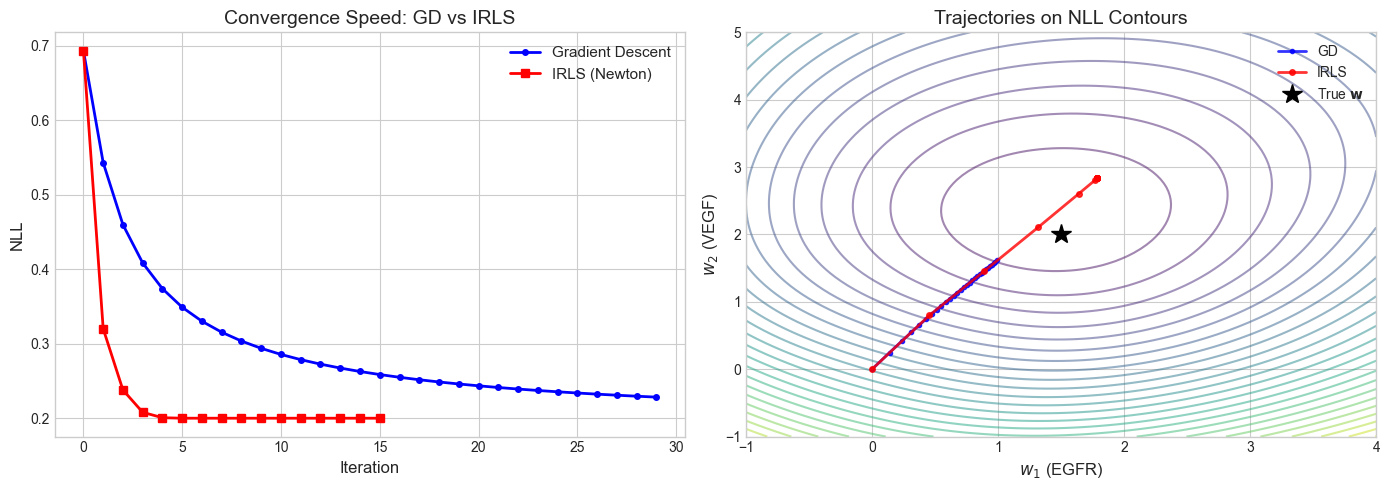

IRLS converges in ~5 iterations — much faster than gradient descent.
Newton's method uses curvature information (Hessian) to take optimal steps.


In [13]:
# Compare convergence speed: GD vs IRLS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: NLL convergence
axes[0].plot(hist_gd['nll'][:30], 'b-o', linewidth=2, markersize=4, label='Gradient Descent')
axes[0].plot(hist_irls['nll'], 'r-s', linewidth=2, markersize=6, label='IRLS (Newton)')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('NLL', fontsize=12)
axes[0].set_title('Convergence Speed: GD vs IRLS', fontsize=14)
axes[0].legend(fontsize=11)

# Right: trajectory on contour
axes[1].contour(W1, W2, NLL_surface, levels=30, cmap='viridis', alpha=0.5)

w_traj_irls = np.array(hist_irls['w'])
axes[1].plot(w_traj_gd[:30, 1], w_traj_gd[:30, 2], 'b.-', markersize=6,
             linewidth=2, alpha=0.8, label='GD')
axes[1].plot(w_traj_irls[:, 1], w_traj_irls[:, 2], 'r.-', markersize=8,
             linewidth=2, alpha=0.8, label='IRLS')
axes[1].plot(w_true[0], w_true[1], 'k*', markersize=15, label='True $\\mathbf{w}$', zorder=5)

axes[1].set_xlabel('$w_1$ (EGFR)', fontsize=12)
axes[1].set_ylabel('$w_2$ (VEGF)', fontsize=12)
axes[1].set_title('Trajectories on NLL Contours', fontsize=14)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

print("IRLS converges in ~5 iterations — much faster than gradient descent.")
print("Newton's method uses curvature information (Hessian) to take optimal steps.")

## 9. MAP Estimation and $\ell_2$ Regularization (Section 10.2.7)

MLE can overfit when the model is too flexible (e.g., polynomial features). A Gaussian prior $p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0}, C\mathbf{I})$ leads to MAP estimation with $\ell_2$ regularization (Eq. 10.47):

$$\mathcal{L}(\mathbf{w}) = \text{NLL}(\mathbf{w}) + \lambda \|\mathbf{w}\|_2^2$$

where $\lambda = 1/C$. The penalized gradient and Hessian (Eqs. 10.49–10.50):

$$\nabla \text{PNLL}(\mathbf{w}) = \mathbf{g}(\mathbf{w}) + 2\lambda \mathbf{w}$$
$$\nabla^2 \text{PNLL}(\mathbf{w}) = \mathbf{H}(\mathbf{w}) + 2\lambda \mathbf{I}$$

Larger $\lambda$ penalizes large weights more, producing a smoother (less flexible) decision boundary.

In [14]:
def irls_regularized(X, y, lam=0.01, n_iters=20):
    """IRLS with L2 regularization (Eqs. 10.48-10.50)."""
    N = len(y)
    D = X.shape[1]
    w = np.zeros(D)
    history = {'w': [w.copy()], 'nll': []}
    
    for t in range(n_iters):
        mu = sigmoid(X @ w)
        s = np.clip(mu * (1 - mu), 1e-10, None)
        
        # Penalized gradient (Eq. 10.49)
        g = X.T @ (mu - y) / N + 2 * lam * w
        
        # Penalized Hessian (Eq. 10.50)
        H = (X.T * s) @ X / N + 2 * lam * np.eye(D)
        
        # Newton step
        w = w - np.linalg.solve(H, g)
        
        pnll = nll(w, X, y) + lam * np.sum(w**2)
        history['w'].append(w.copy())
        history['nll'].append(pnll)
    
    return w, history

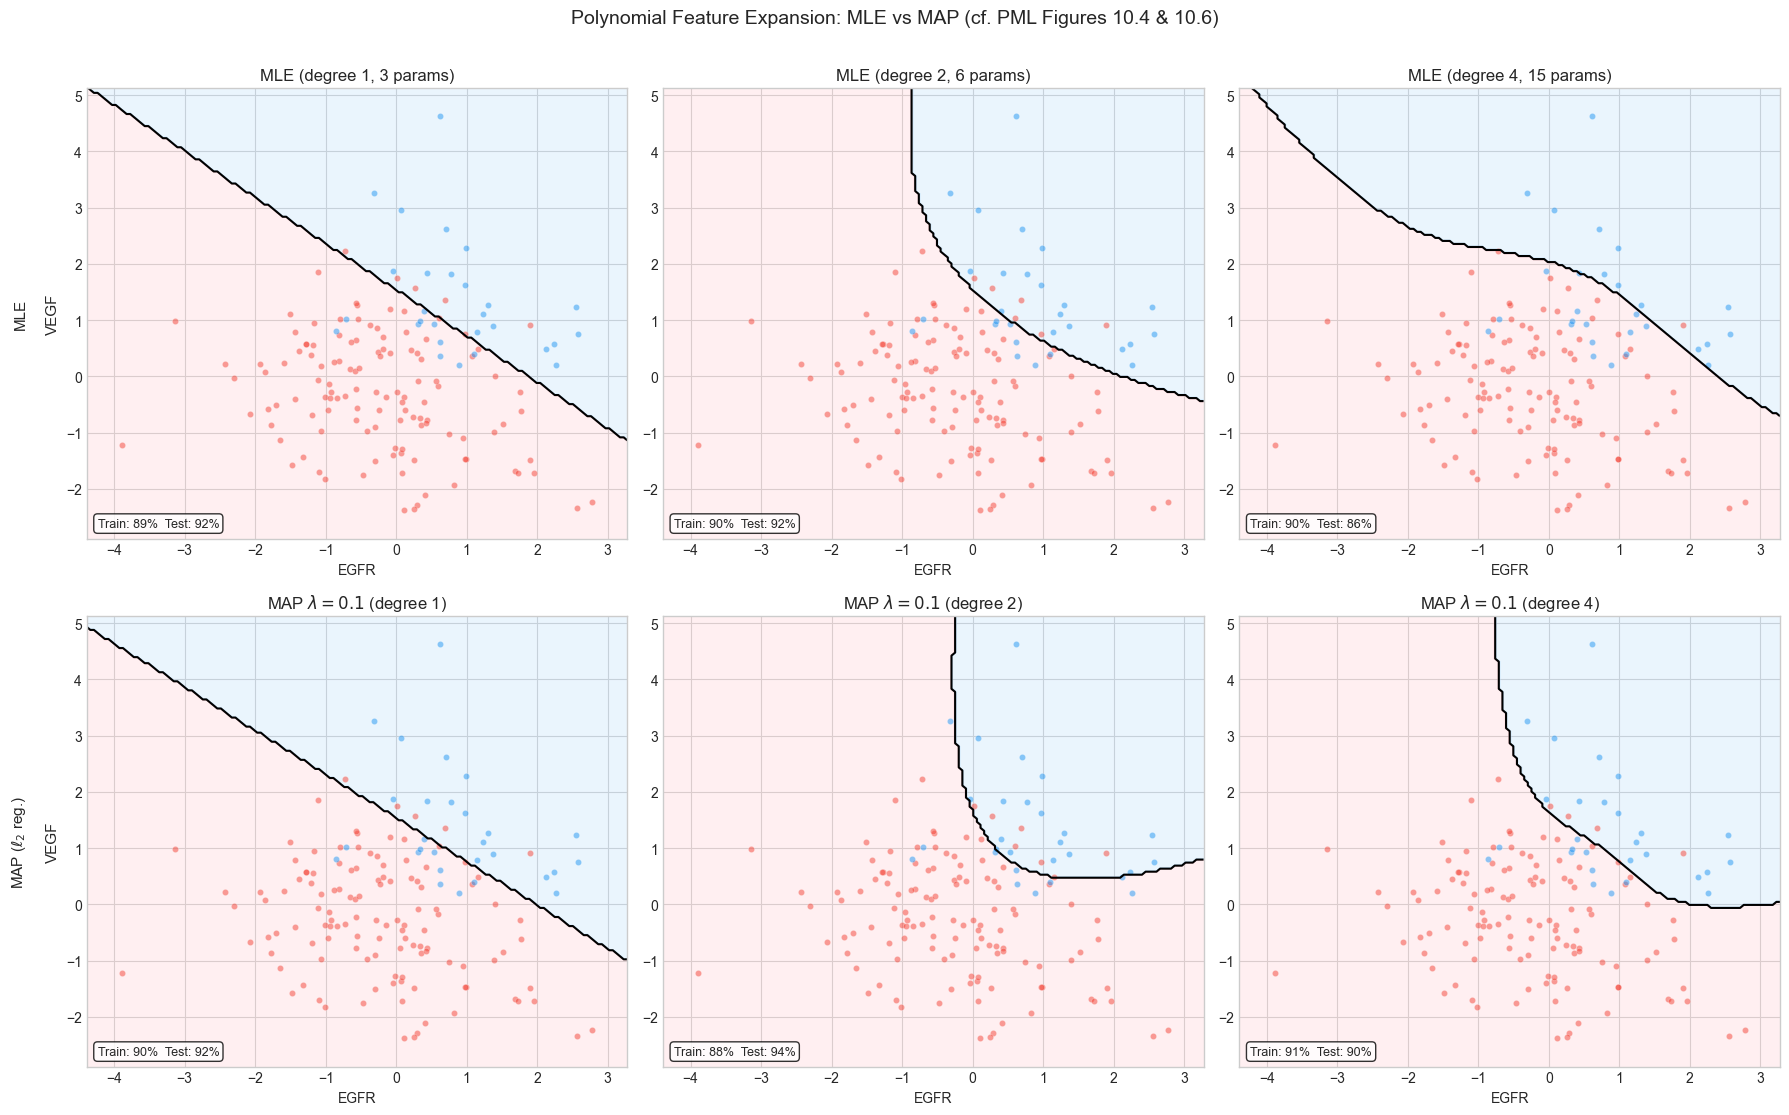

Top row: MLE overfits with higher-degree polynomials (wiggly boundaries).
Bottom row: L2 regularization (MAP) keeps boundaries smooth even at degree 4.


In [15]:
# Demonstrate overfitting with polynomial features and regularization (cf. PML Figure 10.4/10.6)
from itertools import combinations_with_replacement


def polynomial_features(X_raw, degree):
    """Create polynomial features up to given degree."""
    N, d = X_raw.shape
    features = [np.ones(N)]  # bias
    
    for deg in range(1, degree + 1):
        for combo in combinations_with_replacement(range(d), deg):
            feat = np.ones(N)
            for idx in combo:
                feat = feat * X_raw[:, idx]
            features.append(feat)
    
    return np.column_stack(features)


# Split data for train/test evaluation
N_train = 150
X_train_raw, X_test_raw = X_raw[:N_train], X_raw[N_train:]
y_train, y_test = y[:N_train], y[N_train:]

# Create grid for plotting
x1_grid = np.linspace(X_raw[:, 0].min() - 0.5, X_raw[:, 0].max() + 0.5, 150)
x2_grid = np.linspace(X_raw[:, 1].min() - 0.5, X_raw[:, 1].max() + 0.5, 150)
xx_g, yy_g = np.meshgrid(x1_grid, x2_grid)
grid_raw = np.column_stack([xx_g.ravel(), yy_g.ravel()])

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
cmap_bg = ListedColormap(['#FFCDD2', '#BBDEFB'])

degrees = [1, 2, 4]

for col, degree in enumerate(degrees):
    X_poly_train = polynomial_features(X_train_raw, degree)
    X_poly_grid = polynomial_features(grid_raw, degree)
    
    # Unregularized MLE
    w_mle, _ = irls_regularized(X_poly_train, y_train, lam=0.0, n_iters=30)
    preds_mle = (sigmoid(X_poly_grid @ w_mle) > 0.5).astype(int)
    
    # Regularized MAP
    w_map, _ = irls_regularized(X_poly_train, y_train, lam=0.1, n_iters=30)
    preds_map = (sigmoid(X_poly_grid @ w_map) > 0.5).astype(int)
    
    for row, (preds, w_fit, title_suffix) in enumerate([
        (preds_mle, w_mle, f'MLE (degree {degree}, {len(w_mle)} params)'),
        (preds_map, w_map, f'MAP $\\lambda=0.1$ (degree {degree})')
    ]):
        ax = axes[row, col]
        ax.contourf(xx_g, yy_g, preds.reshape(xx_g.shape), alpha=0.3, cmap=cmap_bg)
        ax.contour(xx_g, yy_g, preds.reshape(xx_g.shape), colors='black', linewidths=1.5, levels=[0.5])
        
        for c in range(2):
            mask = y_train == c
            ax.scatter(X_train_raw[mask, 0], X_train_raw[mask, 1],
                       c=colors_cls[c], alpha=0.5, s=20, edgecolors='white', linewidths=0.3)
        
        # Compute accuracy
        X_poly_test = polynomial_features(X_test_raw, degree)
        acc_test = ((sigmoid(X_poly_test @ w_fit) > 0.5).astype(int) == y_test).mean()
        acc_train = ((sigmoid(X_poly_train @ w_fit) > 0.5).astype(int) == y_train).mean()
        
        ax.set_title(title_suffix, fontsize=12)
        ax.text(0.02, 0.02, f'Train: {acc_train:.0%}  Test: {acc_test:.0%}',
                transform=ax.transAxes, fontsize=9, verticalalignment='bottom',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.set_xlabel('EGFR', fontsize=10)
        if col == 0:
            ax.set_ylabel('VEGF', fontsize=10)

axes[0, 0].set_ylabel('MLE\n\nVEGF', fontsize=11)
axes[1, 0].set_ylabel('MAP ($\\ell_2$ reg.)\n\nVEGF', fontsize=11)

plt.suptitle('Polynomial Feature Expansion: MLE vs MAP (cf. PML Figures 10.4 & 10.6)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Top row: MLE overfits with higher-degree polynomials (wiggly boundaries).")
print("Bottom row: L2 regularization (MAP) keeps boundaries smooth even at degree 4.")

## 10. Standardization (Section 10.2.8)

When using an isotropic prior $p(\mathbf{w}) = \mathcal{N}(\mathbf{w} \mid \mathbf{0}, \lambda^{-1}\mathbf{I})$, we assume all weights are similar in magnitude. This requires all features to be on the same scale. **Standardization** (Eq. 10.51):

$$\text{standardize}(x_{nd}) = \frac{x_{nd} - \hat{\mu}_d}{\hat{\sigma}_d}$$

makes each feature have mean 0 and variance 1.

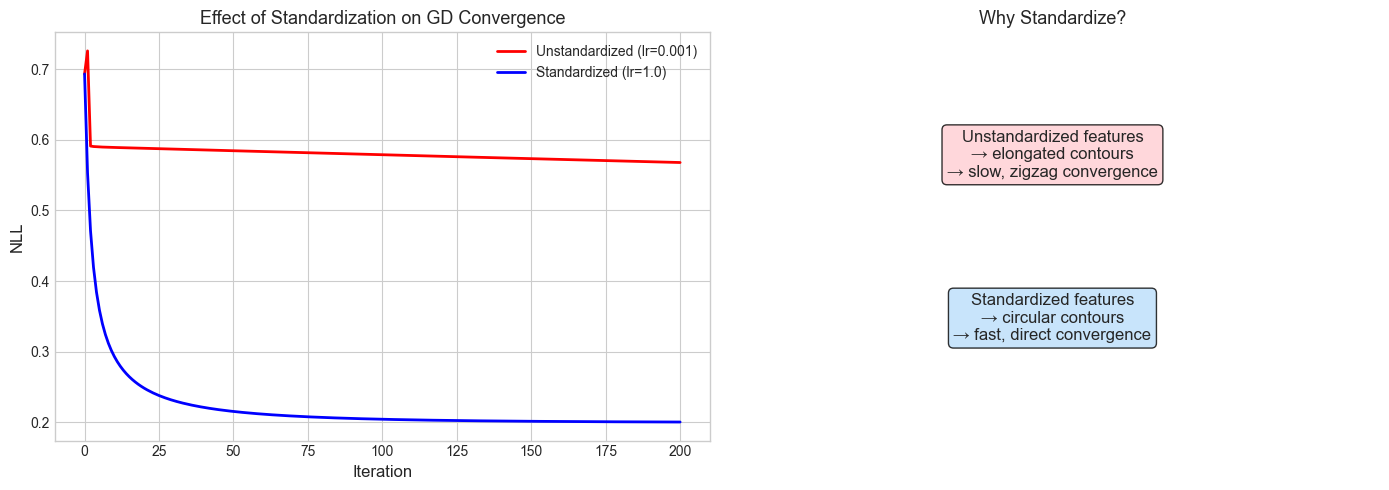

Feature scales before standardization: [  1.14648299 115.50207953]
After standardization: both features have std = 1.0

Unscaled NLL (200 iters): 0.5678
Scaled NLL (200 iters):   0.2006


In [16]:
# Demonstrate the effect of standardization on gradient descent convergence

# Create data with features on very different scales
X_unscaled = X_raw.copy()
X_unscaled[:, 1] = X_raw[:, 1] * 100  # VEGF on a much larger scale

# Standardize (Eq. 10.51)
mu_feat = X_unscaled.mean(axis=0)
sigma_feat = X_unscaled.std(axis=0)
X_standardized = (X_unscaled - mu_feat) / sigma_feat

# Add bias column
X_unscaled_b = np.column_stack([np.ones(N), X_unscaled])
X_standardized_b = np.column_stack([np.ones(N), X_standardized])

# Run gradient descent on both
w_unscaled, hist_unscaled = gradient_descent(X_unscaled_b, y, lr=0.001, n_iters=200)
w_scaled, hist_scaled = gradient_descent(X_standardized_b, y, lr=1.0, n_iters=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist_unscaled['nll'], 'r-', linewidth=2, label='Unstandardized (lr=0.001)')
axes[0].plot(hist_scaled['nll'], 'b-', linewidth=2, label='Standardized (lr=1.0)')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('NLL', fontsize=12)
axes[0].set_title('Effect of Standardization on GD Convergence', fontsize=13)
axes[0].legend(fontsize=10)

# Show the NLL contours for unscaled vs scaled (illustrative 2D)
# Unscaled: elongated contours → slow convergence
# Scaled: circular contours → fast convergence
axes[1].text(0.5, 0.7, 'Unstandardized features\n→ elongated contours\n→ slow, zigzag convergence',
             transform=axes[1].transAxes, fontsize=12, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='#FFCDD2', alpha=0.8))
axes[1].text(0.5, 0.3, 'Standardized features\n→ circular contours\n→ fast, direct convergence',
             transform=axes[1].transAxes, fontsize=12, ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor='#BBDEFB', alpha=0.8))
axes[1].set_title('Why Standardize?', fontsize=13)
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Feature scales before standardization: {sigma_feat}")
print(f"After standardization: both features have std = 1.0")
print(f"\nUnscaled NLL (200 iters): {hist_unscaled['nll'][-1]:.4f}")
print(f"Scaled NLL (200 iters):   {hist_scaled['nll'][-1]:.4f}")

## 11. Nonlinear Classifiers via Feature Expansion (Section 10.2.2)

We can handle nonlinearly separable data by transforming the features through $\phi(\mathbf{x})$ (Eq. 10.5 with feature map):

$$f(\mathbf{x}; \boldsymbol{\theta}) = \mathbf{w}^\top \phi(\mathbf{x})$$

The model is still **linear in the parameters** $\mathbf{w}$, so all the convex optimization theory still applies. But the decision boundary in the original input space can be nonlinear.

Let's create a dataset that is **not** linearly separable and show how polynomial features solve this.

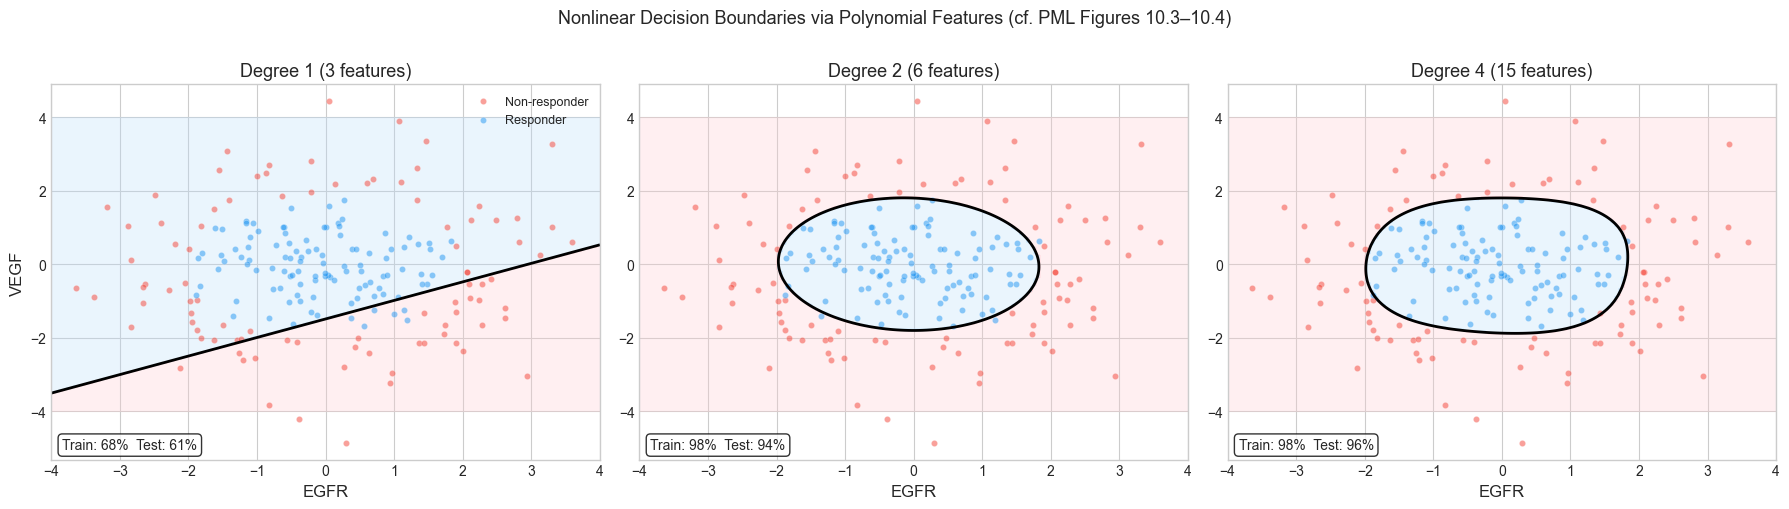

Degree 1 (linear): cannot capture the circular boundary.
Degree 2: quadratic features (x1², x2², x1·x2) capture the circular pattern.
Degree 4: good fit but risk of overfitting with more features.


In [17]:
# Create a nonlinearly separable dataset (cf. PML Figure 10.3)
# Drug response depends on a COMBINATION of biomarkers (interaction effect)
np.random.seed(123)
N_nl = 300
X_nl = np.random.randn(N_nl, 2) * 1.5

# True boundary is a circle: respond if x1^2 + x2^2 < r^2
# (tumors with moderate biomarker levels respond; extreme levels don't)
r_sq = X_nl[:, 0]**2 + X_nl[:, 1]**2
prob_nl = sigmoid(5.0 * (4.0 - r_sq))  # sigmoid of quadratic
y_nl = (np.random.rand(N_nl) < prob_nl).astype(int)

# Split
N_tr_nl = 200
X_nl_train, X_nl_test = X_nl[:N_tr_nl], X_nl[N_tr_nl:]
y_nl_train, y_nl_test = y_nl[:N_tr_nl], y_nl[N_tr_nl:]

# Grid
x1_nl = np.linspace(-4, 4, 150)
x2_nl = np.linspace(-4, 4, 150)
xx_nl, yy_nl = np.meshgrid(x1_nl, x2_nl)
grid_nl = np.column_stack([xx_nl.ravel(), yy_nl.ravel()])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for col, degree in enumerate([1, 2, 4]):
    X_poly = polynomial_features(X_nl_train, degree)
    X_poly_grid = polynomial_features(grid_nl, degree)
    X_poly_test = polynomial_features(X_nl_test, degree)
    
    w_nl, _ = irls_regularized(X_poly, y_nl_train, lam=0.01, n_iters=30)
    probs_grid = sigmoid(X_poly_grid @ w_nl).reshape(xx_nl.shape)
    preds_grid = (probs_grid > 0.5).astype(int)
    
    ax = axes[col]
    ax.contourf(xx_nl, yy_nl, preds_grid, alpha=0.3, cmap=cmap_bg)
    ax.contour(xx_nl, yy_nl, probs_grid, levels=[0.5], colors='black', linewidths=2)
    
    for c in range(2):
        mask = y_nl_train == c
        ax.scatter(X_nl_train[mask, 0], X_nl_train[mask, 1], c=colors_cls[c],
                   alpha=0.5, s=20, edgecolors='white', linewidths=0.3,
                   label=class_names[c] if col == 0 else '')
    
    acc_train = ((sigmoid(X_poly @ w_nl) > 0.5).astype(int) == y_nl_train).mean()
    acc_test = ((sigmoid(X_poly_test @ w_nl) > 0.5).astype(int) == y_nl_test).mean()
    
    ax.set_xlabel('EGFR', fontsize=12)
    if col == 0:
        ax.set_ylabel('VEGF', fontsize=12)
    ax.set_title(f'Degree {degree} ({X_poly.shape[1]} features)', fontsize=13)
    ax.text(0.02, 0.02, f'Train: {acc_train:.0%}  Test: {acc_test:.0%}',
            transform=ax.transAxes, fontsize=10, verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

axes[0].legend(fontsize=9)
plt.suptitle('Nonlinear Decision Boundaries via Polynomial Features (cf. PML Figures 10.3–10.4)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Degree 1 (linear): cannot capture the circular boundary.")
print("Degree 2: quadratic features (x1², x2², x1·x2) capture the circular pattern.")
print("Degree 4: good fit but risk of overfitting with more features.")

## 12. Full Pipeline: Putting It All Together

Let's return to the original (linearly separable) drug response data and compare all methods, including probability calibration.

In [18]:
# Final comparison on the original data
X_train_b = np.column_stack([np.ones(N_train), X_train_raw])
X_test_b = np.column_stack([np.ones(N - N_train), X_test_raw])

# Fit all methods
w_gd_final, _ = gradient_descent(X_train_b, y_train, lr=1.0, n_iters=200)
w_sgd_final, _ = sgd(X_train_b, y_train, lr=0.05, n_epochs=100)
w_irls_final, _ = irls(X_train_b, y_train, n_iters=20)
w_map_final, _ = irls_regularized(X_train_b, y_train, lam=0.1, n_iters=20)
w_perceptron_final, _ = perceptron(X_train_b, y_train, n_epochs=50)

methods_final = [
    ('Gradient Descent', w_gd_final),
    ('SGD', w_sgd_final),
    ('IRLS (Newton)', w_irls_final),
    ('MAP (L2 reg.)', w_map_final),
    ('Perceptron', w_perceptron_final),
]

print("=" * 65)
print(f"{'Method':20s} {'b':>8s} {'w1':>8s} {'w2':>8s} {'Train':>8s} {'Test':>8s}")
print("-" * 65)
print(f"{'True':20s} {b_true:8.3f} {w_true[0]:8.3f} {w_true[1]:8.3f} {'':>8s} {'':>8s}")

for name, w_fit in methods_final:
    pred_train = (sigmoid(X_train_b @ w_fit) > 0.5).astype(int)
    pred_test = (sigmoid(X_test_b @ w_fit) > 0.5).astype(int)
    acc_train = (pred_train == y_train).mean()
    acc_test = (pred_test == y_test).mean()
    print(f"{name:20s} {w_fit[0]:8.3f} {w_fit[1]:8.3f} {w_fit[2]:8.3f} {acc_train:7.1%} {acc_test:7.1%}")

print("=" * 65)

Method                      b       w1       w2    Train     Test
-----------------------------------------------------------------
True                   -3.000    1.500    2.000                  
Gradient Descent       -3.257    1.736    2.111   89.3%   92.0%
SGD                    -3.393    1.803    2.200   89.3%   92.0%
IRLS (Newton)          -3.382    1.804    2.195   89.3%   92.0%
MAP (L2 reg.)          -0.749    0.377    0.486   90.0%   92.0%
Perceptron             -3.000    2.390    2.500   89.3%   86.0%


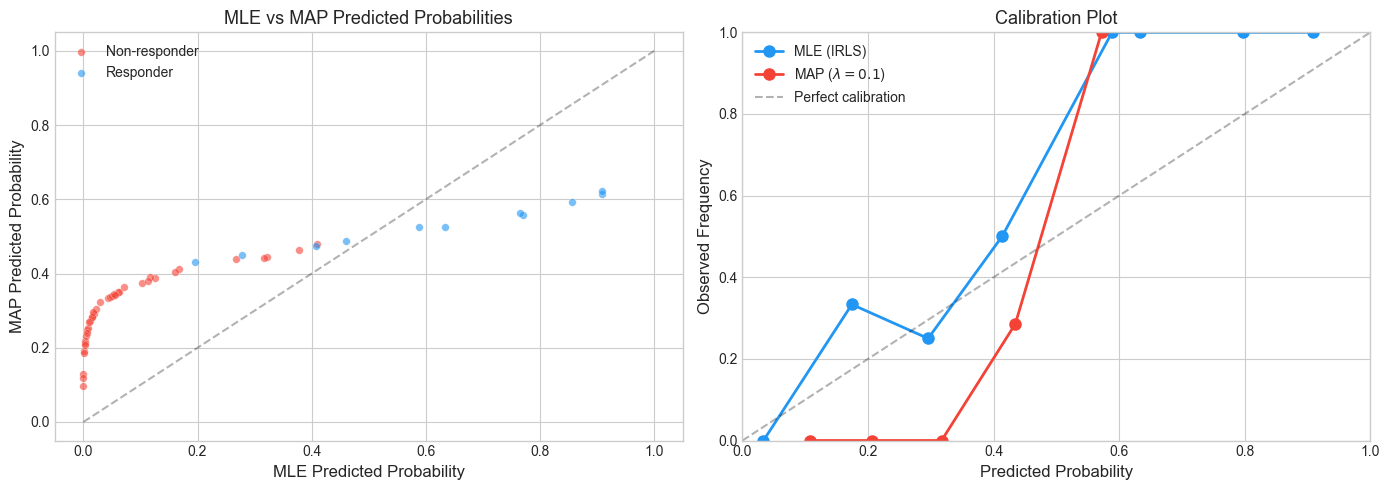

Regularization (MAP) produces more moderate probability estimates,
which can improve calibration — predicted probabilities better match
actual response rates.


In [19]:
# Visualize probability calibration: predicted probability vs actual response rate
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: predicted probabilities on test set (MLE vs MAP)
probs_mle = sigmoid(X_test_b @ w_irls_final)
probs_map = sigmoid(X_test_b @ w_map_final)

for c in range(2):
    mask = y_test == c
    axes[0].scatter(probs_mle[mask], probs_map[mask], c=colors_cls[c],
                    alpha=0.6, s=30, label=class_names[c], edgecolors='white', linewidths=0.3)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('MLE Predicted Probability', fontsize=12)
axes[0].set_ylabel('MAP Predicted Probability', fontsize=12)
axes[0].set_title('MLE vs MAP Predicted Probabilities', fontsize=13)
axes[0].legend(fontsize=10)

# Right: calibration plot
n_bins = 8
for method_probs, label, color in [
    (probs_mle, 'MLE (IRLS)', '#2196F3'),
    (probs_map, 'MAP ($\\lambda=0.1$)', '#F44336')
]:
    bins = np.linspace(0, 1, n_bins + 1)
    bin_centers = []
    bin_true_freqs = []
    
    for i in range(n_bins):
        mask = (method_probs >= bins[i]) & (method_probs < bins[i+1])
        if mask.sum() > 0:
            bin_centers.append(method_probs[mask].mean())
            bin_true_freqs.append(y_test[mask].mean())
    
    axes[1].plot(bin_centers, bin_true_freqs, 'o-', color=color, linewidth=2,
                markersize=8, label=label)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Perfect calibration')
axes[1].set_xlabel('Predicted Probability', fontsize=12)
axes[1].set_ylabel('Observed Frequency', fontsize=12)
axes[1].set_title('Calibration Plot', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Regularization (MAP) produces more moderate probability estimates,")
print("which can improve calibration — predicted probabilities better match")
print("actual response rates.")

## Summary

### Key Takeaways

- **Binary logistic regression** models $p(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)$ using the sigmoid function
- The **decision boundary** is a linear hyperplane defined by $\mathbf{w}^\top \mathbf{x} + b = 0$; its orientation is determined by $\mathbf{w}$, and the confidence by $\|\mathbf{w}\|$
- The **NLL** (binary cross-entropy) is convex — guaranteed global optimum
- **Gradient descent** uses first-order information: $\nabla \text{NLL} = \frac{1}{N} \sum (\mu_n - y_n)\mathbf{x}_n$ (error-weighted inputs)
- **IRLS** (Newton's method) converges much faster by using second-order information (Hessian)
- The **perceptron** is a special case with hard predictions instead of soft probabilities
- **$\ell_2$ regularization** (MAP estimation) prevents overfitting by penalizing large weights
- **Feature standardization** ensures regularization treats all features equally
- **Polynomial features** create nonlinear decision boundaries while keeping the model linear in parameters

### Key Formulas from Chapter 10.2

| Concept | Formula |
|---------|--------|
| Model | $p(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}$ |
| NLL (cross-entropy) | $-\frac{1}{N}\sum [y_n \log \mu_n + (1-y_n)\log(1-\mu_n)]$ |
| Gradient | $\frac{1}{N} \sum (\mu_n - y_n)\mathbf{x}_n$ |
| Hessian | $\frac{1}{N} \mathbf{X}^\top \text{diag}(\mu_n(1-\mu_n)) \mathbf{X} \succcurlyeq 0$ |
| IRLS update | $\mathbf{w} = (\mathbf{X}^\top \mathbf{S} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{S} \mathbf{z}$ |
| MAP objective | $\text{NLL}(\mathbf{w}) + \lambda \|\mathbf{w}\|_2^2$ |